In [ ]:
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [36]:
train, test = keras.datasets.mnist.load_data()

In [37]:
X_train, y_train = train
X_test, y_test = test

In [38]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

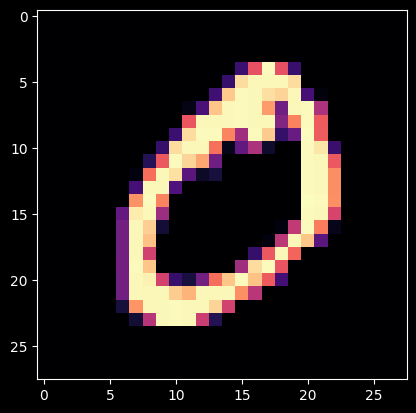

In [39]:
plt.imshow(X_train[1], cmap="magma")

In [40]:
X_train = X_train / 255
X_test = X_test / 255

In [41]:
train_n, train_w, _ = X_train.shape
X_train_flat = X_train.reshape(train_n, train_w * train_w)
X_train.shape

(60000, 28, 28)

In [42]:
test_n, test_w, _ = X_test.shape
X_test_flat = X_test.reshape(test_n, test_w * test_w)
X_test.shape


(10000, 28, 28)

## ADAM


In [ ]:
log_dir_adam = f"./logs/adam/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}_run"
adam_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir_adam, histogram_freq=1)
model_adam = keras.Sequential(
    [
        keras.Input(shape=(train_w, train_w)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

model_adam.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

tf.summary.trace_on(graph=True, profiler=True)

model_adam.fit(
    X_train,
    y_train,
    epochs=5,
    callbacks=[adam_callback],
    validation_data=(X_test, y_test),
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 787us/step - accuracy: 0.9222 - loss: 0.2720 - val_accuracy: 0.9575 - val_loss: 0.1428
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - accuracy: 0.9646 - loss: 0.1209 - val_accuracy: 0.9702 - val_loss: 0.1014
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.9749 - loss: 0.0840 - val_accuracy: 0.9728 - val_loss: 0.0883
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.9805 - loss: 0.0646 - val_accuracy: 0.9735 - val_loss: 0.0869
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.9846 - loss: 0.0507 - val_accuracy: 0.9747 - val_loss: 0.0833


In [44]:
model_adam.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,532 (931.77 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 159,022 (621.18 KB)

In [45]:
model_adam.evaluate(X_test, y_test)
y_hat_adam = model_adam.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.9747 - loss: 0.0833
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step


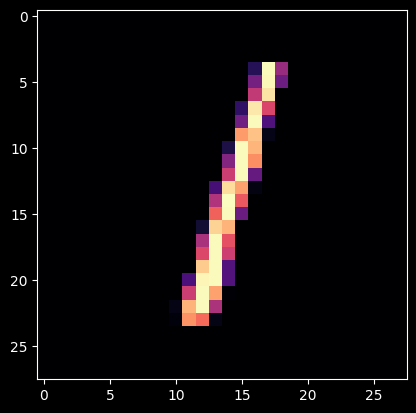

In [46]:
plt.imshow(X_test[2], cmap="magma")
plt.show()

In [47]:
np.argmax(y_hat_adam[2])


1

In [48]:
y_hat_labels_adam = [np.argmax(pred) for pred in y_hat_adam]
y_hat_labels_adam[:5]

[7, 2, 1, 0, 4]

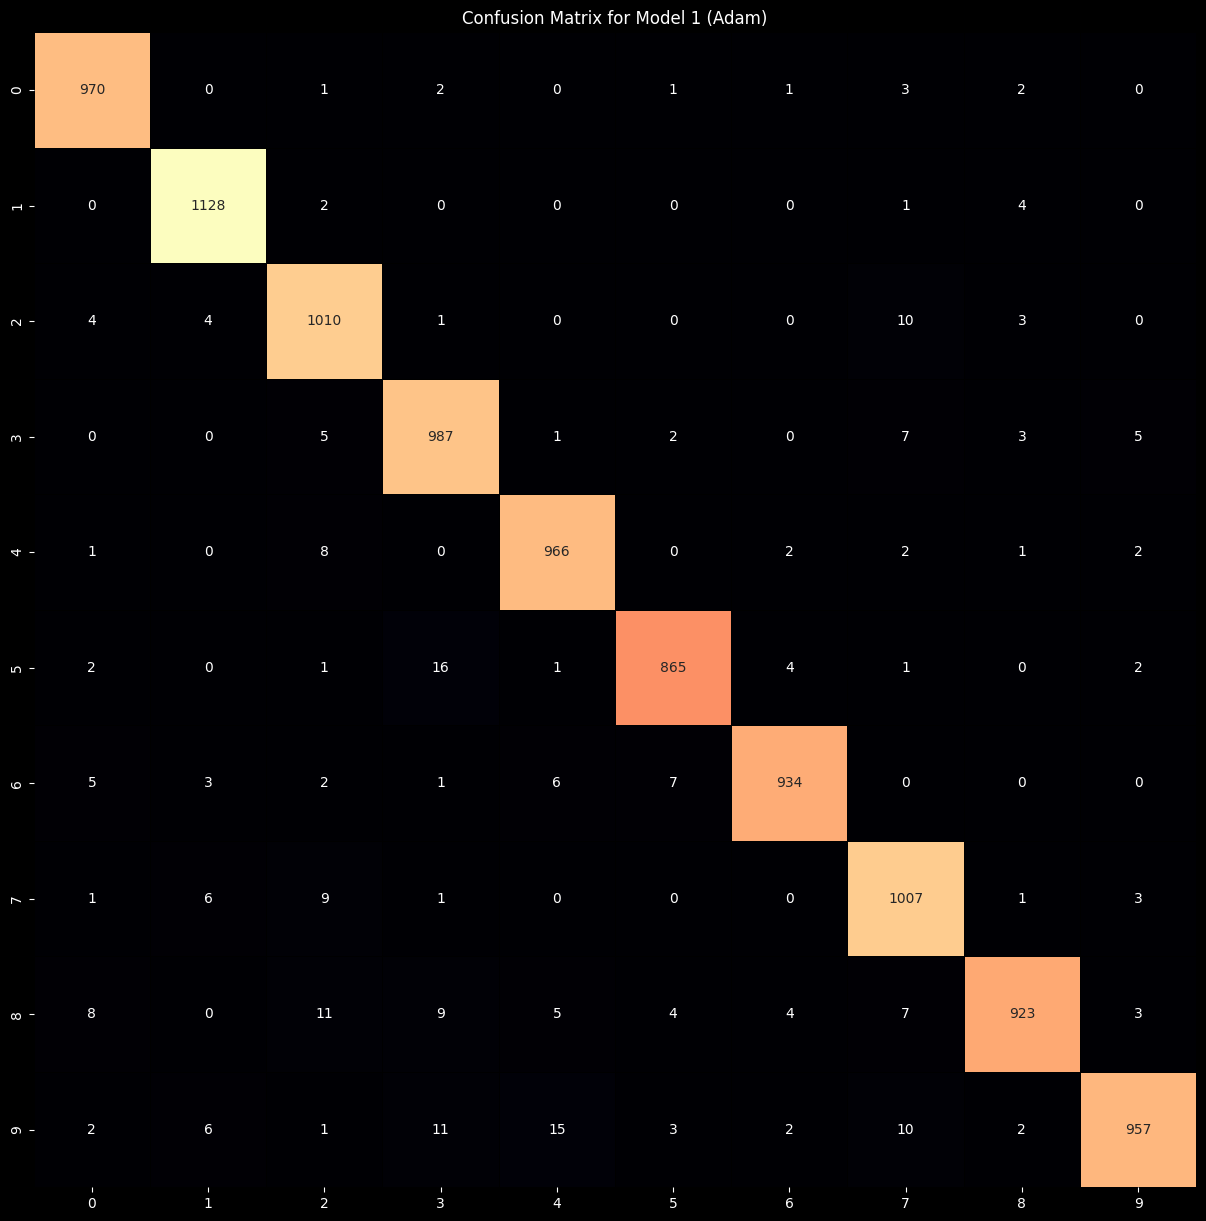

In [49]:
cm_adam = tf.math.confusion_matrix(labels=y_test, predictions=y_hat_labels_adam)
plt.figure(figsize=(15, 15))
sns.heatmap(
    cm_adam,
    cbar=False,
    annot=True,
    fmt="d",
    linecolor="black",
    linewidths=0.5,
    cmap="magma",
)
plt.title("Confusion Matrix for Model 1 (Adam)")
plt.show()

## SGD


In [50]:
log_dir_sgd = f"./logs/sgd/{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}_run"
sgd_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir_sgd, histogram_freq=1)

model_sgd = keras.Sequential(
    [
        keras.Input(shape=(train_w, train_w)),
        keras.layers.Flatten(),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(10, activation="softmax"),
    ]
)

model_sgd.compile(
    optimizer="SGD", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

tf.summary.trace_on(graph=True, profiler=True)

model_sgd.fit(
    X_train,
    y_train,
    epochs=5,
    callbacks=[sgd_callback],
    validation_data=(X_test, y_test),
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.8328 - loss: 0.6555 - val_accuracy: 0.9037 - val_loss: 0.3561
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 588us/step - accuracy: 0.9056 - loss: 0.3391 - val_accuracy: 0.9169 - val_loss: 0.2954
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - accuracy: 0.9175 - loss: 0.2921 - val_accuracy: 0.9247 - val_loss: 0.2666
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 583us/step - accuracy: 0.9254 - loss: 0.2632 - val_accuracy: 0.9324 - val_loss: 0.2426
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 623us/step - accuracy: 0.9314 - loss: 0.2414 - val_accuracy: 0.9356 - val_loss: 0.2262


In [51]:
model_sgd.evaluate(X_test, y_test)
y_hat_sgd = model_sgd.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - accuracy: 0.9356 - loss: 0.2262
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step


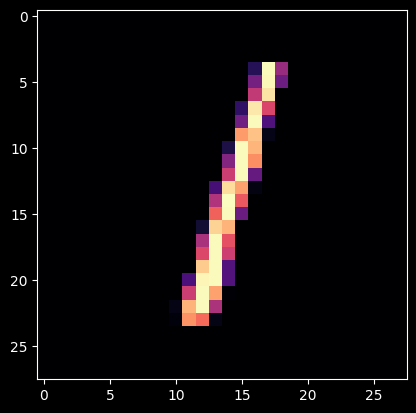

In [52]:
plt.imshow(X_test[2], cmap="magma")
plt.show()

In [53]:
np.argmax(y_hat_adam[2])


1

In [54]:
y_hat_labels_sgd = [np.argmax(pred) for pred in y_hat_sgd]
y_hat_labels_sgd[:5]

[7, 2, 1, 0, 4]

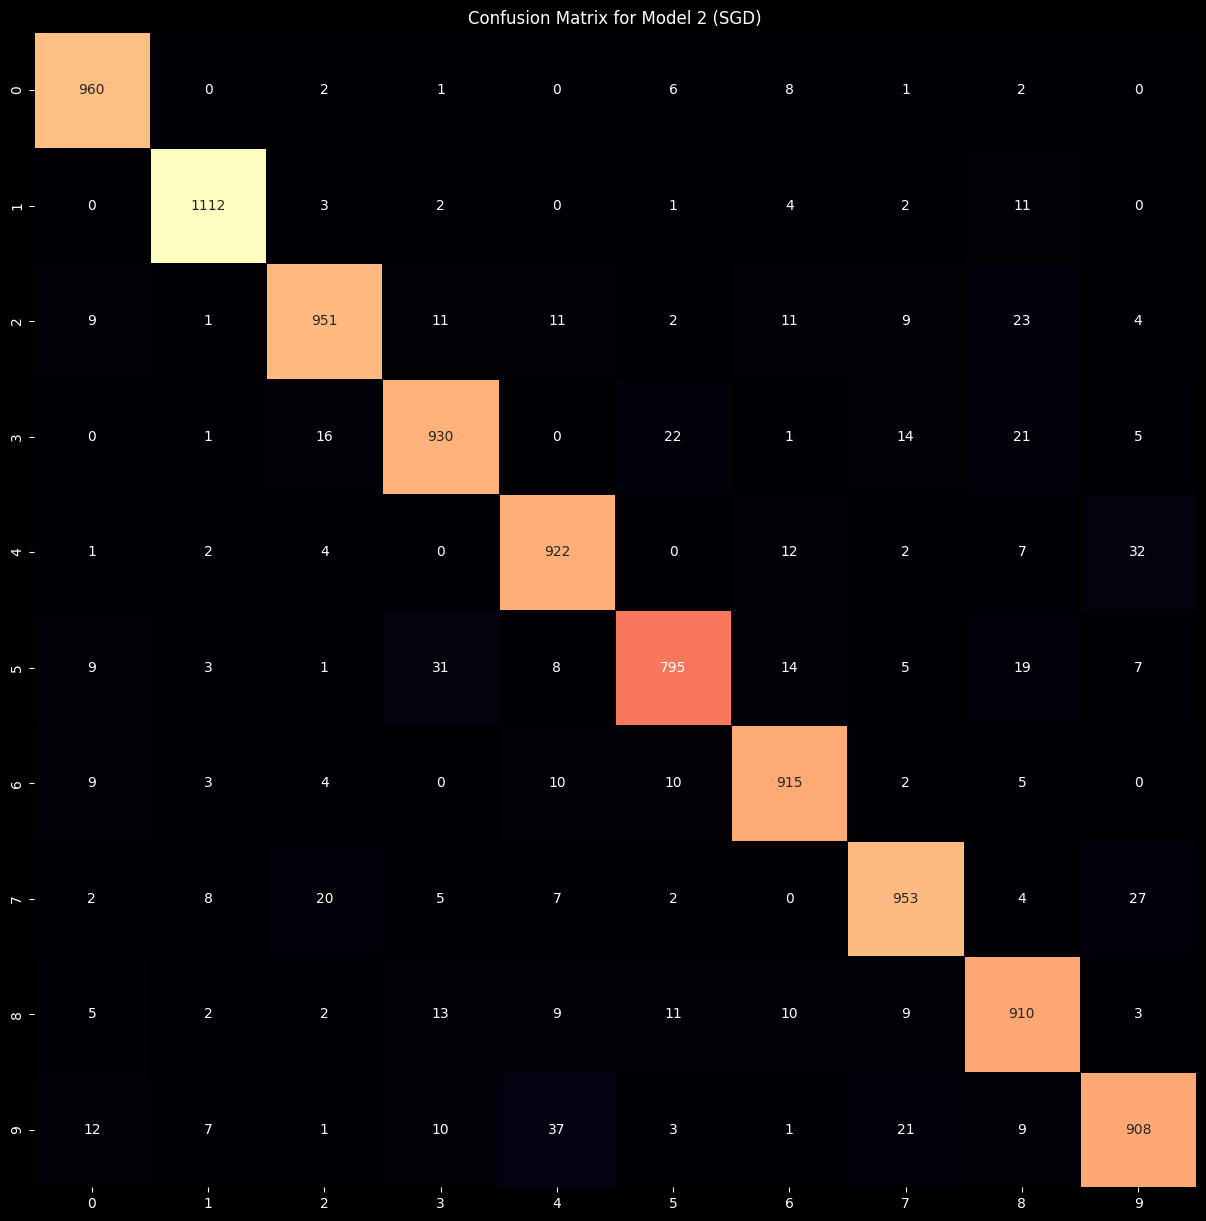

In [55]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_hat_labels_sgd)
plt.figure(figsize=(15, 15))
sns.heatmap(
    cm,
    cbar=False,
    annot=True,
    fmt="d",
    linecolor="black",
    linewidths=0.5,
    cmap="magma",
)
plt.title("Confusion Matrix for Model 2 (SGD)")
plt.show()

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir logs/